# Linear and Multiple Regression — Advanced Practice Within Lecture Scope

## Student Workbook

This notebook is based only on the concepts covered in the lecture:

- Preparing \(X\) and \(y\)
- Initializing parameters
- Making predictions
- Calculating prediction error
- Cost function
- Gradient Descent
- Learning rate
- Best-fit line
- Multiple Linear Regression
- Coefficient interpretation
- Vectorized form
- Regression evaluation
- `scikit-learn` workflow

The tasks are challenging, but they do not require concepts outside the lecture.

## General Instructions

For every task:

1. Show your calculations or code clearly.
2. Explain the result in words.
3. Do not use `scikit-learn` in the from-scratch tasks.
4. Use `scikit-learn` only when the task explicitly requests it.
5. Interpret the intercept, slope, coefficients, errors, and metrics.

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


# Task 1 — Compare Candidate Regression Lines

A model uses:

$$
\hat{y} = \theta_0 + \theta_1x
$$

You are given a small dataset and three candidate parameter pairs.

### Required

1. Calculate predictions for every candidate.
2. Calculate the error for every observation.
3. Calculate the cost:

$$
J(\theta_0,\theta_1)
=
\frac{1}{2m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})^2
$$

4. Create a comparison table.
5. Select the candidate with the lowest cost.
6. Plot all candidate lines with the data.

In [2]:
task1_df = pd.DataFrame({
    "x": [1, 2, 3, 4, 5],
    "y": [7, 9, 13, 15, 18]
})

candidate_parameters = {
    "Candidate A": (0, 3),
    "Candidate B": (4, 2.5),
    "Candidate C": (6, 2)
}

display(task1_df)

,x,y
0,1,7
1,2,9
2,3,13
3,4,15
4,5,18


     Candidate                   Predictions                         Errors  \
0  Candidate A             [3, 6, 9, 12, 15]           [-4, -3, -4, -3, -3]   
1  Candidate B  [6.5, 9.0, 11.5, 14.0, 16.5]  [-0.5, 0.0, -1.5, -1.0, -1.5]   
2  Candidate C           [8, 10, 12, 14, 16]             [1, 1, -1, -1, -2]   

    Cost  
0  5.900  
1  0.575  
2  0.800  

Best Candidate:
Candidate                        Candidate B
Predictions     [6.5, 9.0, 11.5, 14.0, 16.5]
Errors         [-0.5, 0.0, -1.5, -1.0, -1.5]
Cost                                   0.575
Name: 1, dtype: object


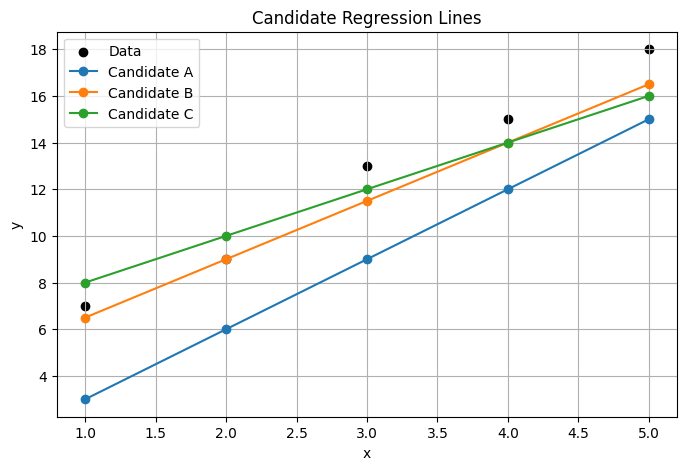

In [3]:
# TODO: Complete Task 1.

import pandas as pd
import matplotlib.pyplot as plt

# Dataset
task1_df = pd.DataFrame({
    "x": [1, 2, 3, 4, 5],
    "y": [7, 9, 13, 15, 18]
})

# Candidate parameters
candidate_parameters = {
    "Candidate A": (0, 3),
    "Candidate B": (4, 2.5),
    "Candidate C": (6, 2)
}

comparison = []
m = len(task1_df)

for candidate, (theta0, theta1) in candidate_parameters.items():

    # Predictions
    predictions = theta0 + theta1 * task1_df["x"]

    # Errors
    errors = predictions - task1_df["y"]

    # Cost
    cost = ((errors ** 2).sum()) / (2 * m)

    comparison.append({
        "Candidate": candidate,
        "Predictions": predictions.tolist(),
        "Errors": errors.tolist(),
        "Cost": cost
    })

# Comparison table
comparison_df = pd.DataFrame(comparison)
print(comparison_df)

# Candidate with the lowest cost
best_candidate = comparison_df.loc[comparison_df["Cost"].idxmin()]
print("\nBest Candidate:")
print(best_candidate)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(task1_df["x"], task1_df["y"], color="black", label="Data")

for candidate, (theta0, theta1) in candidate_parameters.items():
    predictions = theta0 + theta1 * task1_df["x"]
    plt.plot(task1_df["x"], predictions, marker="o", label=candidate)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Candidate Regression Lines")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation Questions

1. Which candidate produced the lowest cost?
2. Did the best line pass through every point?
3. Why is the lowest-cost line considered the best among these candidates?

In [ ]:
# Write your answers as comments.
#the best candidit was B , with the least cost value B, because it is the closest to the data points and has the smallest prediction errors, which gives it the lowest cost."

# Task 2 — Perform One Gradient Descent Update

Use the following equations:

Prediction:

$$
\hat{y}^{(i)} = \theta_0 + \theta_1x^{(i)}
$$

Gradients:

$$
\frac{\partial J}{\partial\theta_0}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})
$$

$$
\frac{\partial J}{\partial\theta_1}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}^{(i)}-y^{(i)})x^{(i)}
$$

Updates:

$$
\theta_0 := \theta_0 - \alpha \frac{\partial J}{\partial\theta_0}
$$

$$
\theta_1 := \theta_1 - \alpha \frac{\partial J}{\partial\theta_1}
$$

### Required

Start with:

- \(\theta_0 = 0\)
- \(\theta_1 = 0\)
- \(\alpha = 0.01\)

Then:

1. Calculate the initial predictions.
2. Calculate both gradients.
3. Update both parameters once.
4. Calculate the cost before and after the update.
5. Explain whether the update improved the model.

In [5]:
task2_df = pd.DataFrame({
    "x": [1, 2, 3, 4],
    "y": [5, 8, 11, 14]
})

display(task2_df)

,x,y
0,1,5
1,2,8
2,3,11
3,4,14


In [6]:
# TODO: Complete Task 2.
theta0 = 0
theta1 = 0
alpha = 0.01
m = len(task2_df)
x = task2_df["x"]
y = task2_df["y"]


def predictions(theta0: float, theta1: float, x) -> float:
    return theta0 + theta1 * x


def gradian_theta0(y_hat, y) -> float:
    return (y_hat - y).sum() / m


def gradian_theta1(y_hat, y, x) -> float:
    return ((y_hat - y) * x).sum() / m


def update_theta0(theta0: float, alpha: float, gradian_theta0: float) -> float:
    return theta0 - alpha * gradian_theta0


def update_theta1(theta1: float, alpha: float, gradian_theta1: float) -> float:
    return theta1 - alpha * gradian_theta1


def cost_function(y_hat, y) -> float:
    return ((y_hat - y) ** 2).sum() / (2 * m)


initial_predictions = predictions(theta0, theta1, x)
print("Initial predictions:", initial_predictions.tolist())

gradian_theta0_value = gradian_theta0(initial_predictions, y)
gradian_theta1_value = gradian_theta1(initial_predictions, y, x)
print("Gradient theta0:", gradian_theta0_value)
print("Gradient theta1:", gradian_theta1_value)

cost_before_update = cost_function(initial_predictions, y)

new_theta0 = update_theta0(theta0, alpha, gradian_theta0_value)
new_theta1 = update_theta1(theta1, alpha, gradian_theta1_value)
print("Updated theta0:", new_theta0)
print("Updated theta1:", new_theta1)

updated_predictions = predictions(new_theta0, new_theta1, x)
cost_after_update = cost_function(updated_predictions, y)

print(f"Cost before update: {cost_before_update:.4f}")
print(f"Cost after update: {cost_after_update:.4f}")
print("Improved:", cost_after_update < cost_before_update)


Initial predictions: [0, 0, 0, 0]
Gradient theta0: -9.5
Gradient theta1: -27.5
Updated theta0: 0.095
Updated theta1: 0.275
Cost before update: 50.7500
Cost after update: 42.6384
Improved: True


### Interpretation Questions

1. Did the cost decrease after one update?
2. Why must both gradients be calculated before updating either parameter?
3. What would happen if the learning rate were zero?

In [7]:
# Write your answers as comments.
# Yes
# Because we have to know if it improved before updating the parameters.
# If the learning rate were zero, the parameters would not be updated at all, and the model would not learn from the data.

# Task 3 — Build Simple Linear Regression from Scratch

Build a complete Simple Linear Regression model without `scikit-learn`.

### Required Functions

1. `predict()`
2. `compute_cost()`
3. `compute_gradients()`
4. `gradient_descent()`

### Required Outputs

- Learned intercept
- Learned slope
- Final equation
- Cost history
- Best-fit line
- Prediction table
- MAE, MSE, RMSE, and \(R^2\)
- Prediction for \(x=7.5\)

In [8]:
task3_df = pd.DataFrame({
    "study_hours": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    "score": [45, 50, 56, 60, 65, 72, 78, 83, 88, 94]
})

display(task3_df)

,study_hours,score
0,1,45
1,2,50
2,3,56
3,4,60
4,5,65
5,6,72
6,7,78
7,8,83
8,9,88
9,10,94


### Hints

- Use NumPy arrays.
- Start with `theta_0 = 0` and `theta_1 = 0`.
- Try `learning_rate = 0.01`.
- Try `iterations = 2000`.
- Store the cost after every iteration.

Learned intercept (theta_0): 38.4408
Learned slope (theta_1): 5.5531
Final equation: y_hat = 38.4408 + 5.5531 * x


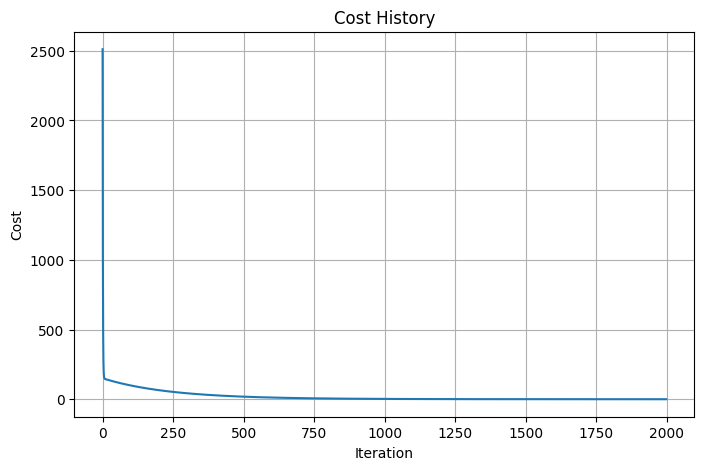

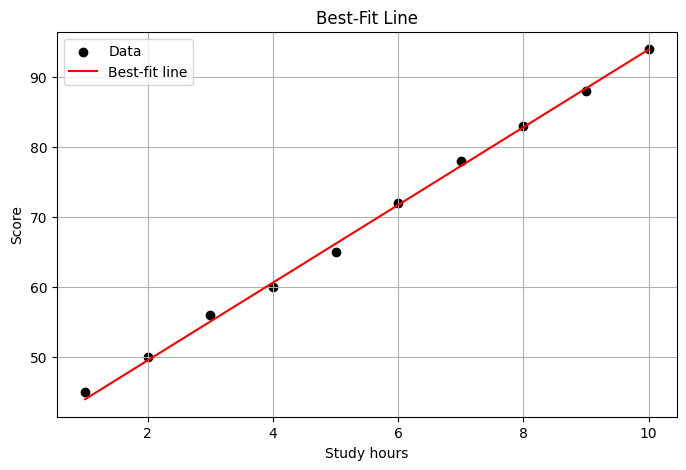

,study_hours,actual_score,predicted_score,residual
0,1,45,43.993818,1.006182
1,2,50,49.546874,0.453126
2,3,56,55.099931,0.900069
3,4,60,60.652988,-0.652988
4,5,65,66.206044,-1.206044
5,6,72,71.759101,0.240899
6,7,78,77.312158,0.687842
7,8,83,82.865214,0.134786
8,9,88,88.418271,-0.418271
9,10,94,93.971328,0.028672


MAE: 0.5729
MSE: 0.4634
RMSE: 0.6807
R2: 0.9981
Predicted score for 7.5 study hours: 80.0887


In [9]:
# TODO: Complete Task 3.
x = np.array(task3_df["study_hours"])
y = np.array(task3_df["score"])
m = len(x)

def predict(theta_0: float, theta_1: float, x: np.ndarray) -> np.ndarray:
    return theta_0 + theta_1 * x

def compute_cost(y_hat: np.ndarray, y: np.ndarray) -> float:
    return ((y_hat - y) ** 2).sum() / (2 * m)

def compute_gradients(y_hat: np.ndarray, y: np.ndarray, x: np.ndarray) -> tuple:
    gradient_theta_0 = (y_hat - y).sum() / m
    gradient_theta_1 = ((y_hat - y) * x).sum() / m

    return gradient_theta_0, gradient_theta_1

def gradient_descent(x: np.ndarray, y: np.ndarray, learning_rate: float, iterations: int) -> tuple:
    theta_0 = 0
    theta_1 = 0
    cost_history = []

    for i in range(iterations):
        y_hat = predict(theta_0, theta_1, x)
        cost_history.append(compute_cost(y_hat, y))
        gradient_theta_0, gradient_theta_1 = compute_gradients(y_hat, y, x)
        theta_0 = theta_0 - learning_rate * gradient_theta_0
        theta_1 = theta_1 - learning_rate * gradient_theta_1

    return theta_0, theta_1, cost_history

learning_rate = 0.01
iterations = 2000
theta_0, theta_1, cost_history = gradient_descent(x, y, learning_rate, iterations)

print(f"Learned intercept (theta_0): {theta_0:.4f}")
print(f"Learned slope (theta_1): {theta_1:.4f}")
print(f"Final equation: y_hat = {theta_0:.4f} + {theta_1:.4f} * x")

plt.figure(figsize=(8, 5))
plt.plot(range(iterations), cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost History")
plt.grid(True)
plt.show()

predictions = predict(theta_0, theta_1, x)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, color="black", label="Data")
plt.plot(x, predictions, color="red", label="Best-fit line")
plt.xlabel("Study hours")
plt.ylabel("Score")
plt.title("Best-Fit Line")
plt.legend()
plt.grid(True)
plt.show()

residuals = []
for i in range(m):
    residuals.append(y[i] - predictions[i])

prediction_table = pd.DataFrame({
    "study_hours": x,
    "actual_score": y,
    "predicted_score": predictions,
    "residual": residuals
})
display(prediction_table)

absolute_errors = []
for i in range(m):
    absolute_errors.append(abs(y[i] - predictions[i]))
mae = sum(absolute_errors) / m

squared_errors = []
for i in range(m):
    squared_errors.append((y[i] - predictions[i]) ** 2)
mse = sum(squared_errors) / m

rmse = mse ** 0.5

mean_y = y.sum() / m
total_squares = []
for i in range(m):
    total_squares.append((y[i] - mean_y) ** 2)
r2 = 1 - sum(squared_errors) / sum(total_squares)

print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

new_study_hours = 7.5
new_prediction = predict(theta_0, theta_1, new_study_hours)
print(f"Predicted score for {new_study_hours} study hours: {new_prediction:.4f}")

### Interpretation Questions

1. What does the learned slope mean?
2. Is the intercept practically meaningful?
3. Did the cost decrease smoothly?
4. Why does the best-fit line not need to pass through every point?

In [10]:
# Write your answers as comments.
# The learned slope means that for every additional hour of study the student's score is expected to increase by the value of the slope.
# Yes, the intercept represents the expected score when the student studies for zero hours, which may not be practically meaningful.
# Yes, the cost decreased smoothly during the iterations, indicating stable training.
# The best-fit line represents the average relationship between the variables and minimizes the sum of squared residuals, so it doesn't need to pass through every point.

# Task 4 — Learning Rate Experiment

Use the same dataset from Task 3.

Train the manual Gradient Descent model using:

- `learning_rate = 0.001`
- `learning_rate = 0.01`
- `learning_rate = 0.1`

Use the same number of iterations for all experiments.

### Required

1. Store the final cost for each learning rate.
2. Plot the cost history separately for each learning rate.
3. Identify stable, slow, or divergent training.
4. Create a comparison table.

C:\Users\khali\AppData\Local\Temp\ipykernel_15508\1167461909.py:10: RuntimeWarning: overflow encountered in square
  return ((y_hat - y) ** 2).sum() / (2 * m)
c:\Users\khali\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\khali\AppData\Local\Temp\ipykernel_15508\1167461909.py:28: RuntimeWarning: invalid value encountered in scalar subtract
  theta_1 = theta_1 - learning_rate * gradient_theta_1


Learning rate 0.001: final cost = 65.07530326660394
Learning rate 0.01: final cost = 0.23183545436330072
Learning rate 0.1: final cost = nan


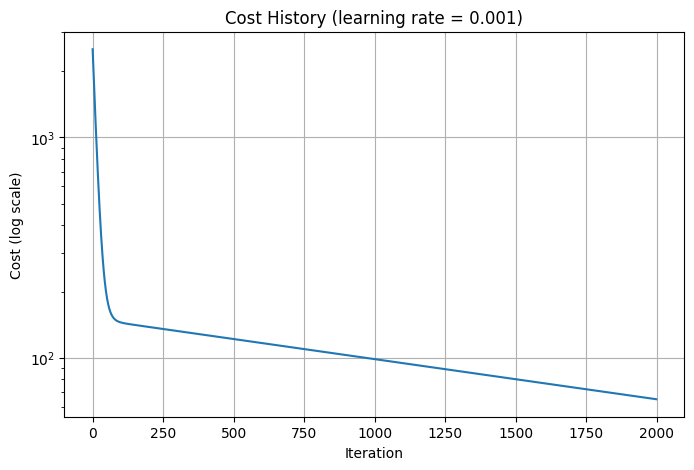

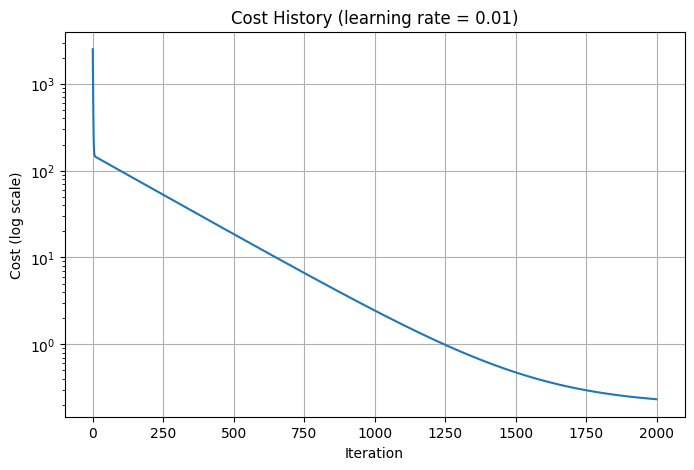

c:\Users\khali\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\scale.py:270: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


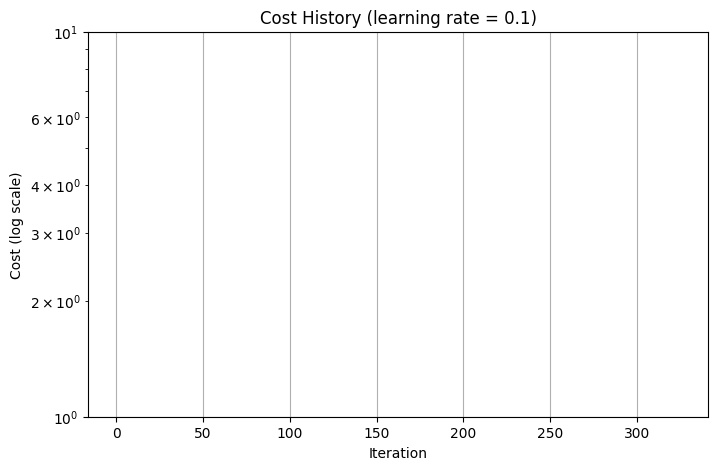

Learning rate 0.001: Slow
Learning rate 0.01: Stable
Learning rate 0.1: Divergent


,learning_rate,initial_cost,final_cost,theta_0,theta_1,behaviour
0,0.001,2511.15,65.075303,14.399211,9.006398,Slow
1,0.010,2511.15,0.231835,38.440761,5.553057,Stable
2,0.100,2511.15,NaN,NaN,NaN,Divergent


In [11]:
# TODO: Complete Task 4 using your functions from Task 3.
# TODO: Complete Task 4 using your functions from Task 3.
learning_rates = [0.001, 0.01, 0.1]
iterations = 2000

experiment_results = {}
for learning_rate in learning_rates:
    theta_0, theta_1, cost_history = gradient_descent(x, y, learning_rate, iterations)
    experiment_results[learning_rate] = (theta_0, theta_1, cost_history)

final_costs = {}
for learning_rate in learning_rates:
    cost_history = experiment_results[learning_rate][2]
    final_costs[learning_rate] = cost_history[-1]
    print(f"Learning rate {learning_rate}: final cost = {cost_history[-1]}")

for learning_rate in learning_rates:
    cost_history = experiment_results[learning_rate][2]
    plt.figure(figsize=(8, 5))
    plt.plot(range(iterations), cost_history)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Cost (log scale)")
    plt.title(f"Cost History (learning rate = {learning_rate})")
    plt.grid(True)
    plt.show()

lowest_final_cost = min(final_costs.values())

behaviours = {}
for learning_rate in learning_rates:
    cost_history = experiment_results[learning_rate][2]
    if not np.isfinite(cost_history[-1]) or cost_history[-1] > cost_history[0]:
        behaviours[learning_rate] = "Divergent"
    elif cost_history[-1] > 10 * lowest_final_cost:
        behaviours[learning_rate] = "Slow"
    else:
        behaviours[learning_rate] = "Stable"
    print(f"Learning rate {learning_rate}: {behaviours[learning_rate]}")

comparison_rows = []
for learning_rate in learning_rates:
    theta_0, theta_1, cost_history = experiment_results[learning_rate]
    comparison_rows.append({
        "learning_rate": learning_rate,
        "initial_cost": cost_history[0],
        "final_cost": cost_history[-1],
        "theta_0": theta_0,
        "theta_1": theta_1,
        "behaviour": behaviours[learning_rate]
    })

comparison_df = pd.DataFrame(comparison_rows)
display(comparison_df)


### Interpretation Questions

1. Which learning rate converged fastest?
2. Which learning rate was too small or too large?
3. What pattern indicates divergence?
4. Why can the best learning rate depend on the scale of \(X\)?

In [14]:
# Write your answers as comments.
# 0.01
# 0.001 was too slow to converge.
# 0.1 was too large and caused divergence because it overshot the minimum.
# The learning rate depends on the scale of X because if the scale of X is large, a smaller learning rate may be needed to ensure stable convergence.

# Task 5 — Multiple Linear Regression by Manual Substitution

A house-price model is:

$$
\hat{y}
=
\theta_0
+
\theta_1x_1
+
\theta_2x_2
+
\theta_3x_3
$$

Where:

- \(x_1\): area in m²
- \(x_2\): number of bedrooms
- \(x_3\): property age in years

The learned parameters are:

- \(\theta_0 = 120\)
- \(\theta_1 = 3.5\)
- \(\theta_2 = 25\)
- \(\theta_3 = -2\)

Prices are measured in thousands.

### Required

1. Predict the price for each property.
2. Calculate residuals.
3. Interpret every coefficient.
4. Predict a new property with:
   - Area = 180
   - Bedrooms = 4
   - Age = 8
5. Explain “holding other features constant.”

In [15]:
task5_df = pd.DataFrame({
    "area_m2": [100, 140, 180, 220],
    "bedrooms": [2, 3, 4, 5],
    "property_age": [20, 12, 8, 4],
    "actual_price_thousands": [470, 650, 845, 1035]
})

theta_0 = 120
theta_1 = 3.5
theta_2 = 25
theta_3 = -2

display(task5_df)

,area_m2,bedrooms,property_age,actual_price_thousands
0,100,2,20,470
1,140,3,12,650
2,180,4,8,845
3,220,5,4,1035


In [17]:
# TODO: Complete Task 5.
def predict_price(area_m2: float, bedrooms: float, property_age: float) -> float:
    return theta_0 + theta_1 * area_m2 + theta_2 * bedrooms + theta_3 * property_age


predicted_prices = []
for i in range(len(task5_df)):
    area_m2 = task5_df["area_m2"][i]
    bedrooms = task5_df["bedrooms"][i]
    property_age = task5_df["property_age"][i]
    predicted_prices.append(predict_price(area_m2, bedrooms, property_age))

residuals = []
for i in range(len(task5_df)):
    residuals.append(task5_df["actual_price_thousands"][i] - predicted_prices[i])

prediction_table = pd.DataFrame({
    "area_m2": task5_df["area_m2"],
    "bedrooms": task5_df["bedrooms"],
    "property_age": task5_df["property_age"],
    "actual_price_thousands": task5_df["actual_price_thousands"],
    "predicted_price_thousands": predicted_prices,
    "residual": residuals
})
display(prediction_table)

print(f"Intercept (theta_0 = {theta_0}): base price in thousands when area, bedrooms and age are all zero.")
print(f"Area (theta_1 = {theta_1}): each extra square metre adds {theta_1} thousand, holding other features constant.")
print(f"Bedrooms (theta_2 = {theta_2}): each extra bedroom adds {theta_2} thousand, holding other features constant.")
print(f"Property age (theta_3 = {theta_3}): each extra year of age subtracts {abs(theta_3)} thousand, holding other features constant.")

new_area_m2 = 180
new_bedrooms = 4
new_property_age = 8
new_prediction = predict_price(new_area_m2, new_bedrooms, new_property_age)
print(f"Predicted price for area {new_area_m2}, {new_bedrooms} bedrooms, age {new_property_age}: {new_prediction:.2f} thousand")

print("Holding other features constant means a coefficient measures the change in the predicted price when only that feature changes by one unit and every other feature keeps its current value.")


,area_m2,bedrooms,property_age,actual_price_thousands,predicted_price_thousands,residual
0,100,2,20,470,480.0,-10.0
1,140,3,12,650,661.0,-11.0
2,180,4,8,845,834.0,11.0
3,220,5,4,1035,1007.0,28.0


Intercept (theta_0 = 120): base price in thousands when area, bedrooms and age are all zero.
Area (theta_1 = 3.5): each extra square metre adds 3.5 thousand, holding other features constant.
Bedrooms (theta_2 = 25): each extra bedroom adds 25 thousand, holding other features constant.
Property age (theta_3 = -2): each extra year of age subtracts 2 thousand, holding other features constant.
Predicted price for area 180, 4 bedrooms, age 8: 834.00 thousand
Holding other features constant means a coefficient measures the change in the predicted price when only that feature changes by one unit and every other feature keeps its current value.


### Interpretation Questions

1. What does the area coefficient mean?
2. Why is the property-age coefficient negative?
3. Can the size of coefficients be compared directly when units differ?
4. Does a negative coefficient prove causation?

In [24]:
# Write your answers as comments.
# Each extra square metre adds 3.5 thousand to the price, keeping the other features constant.
# Older properties are worth less, so each extra year subtracts 2000.
# No, The units differ, so a bigger number does not mean a more important feature.
# No, it only shows an association in this data, not that age causes the lower price.

# Task 6 — Vectorized Multiple Regression

Use the vectorized equation:

$$
\hat{y} = X\theta
$$

Include an intercept column of ones in \(X\).

### Required

1. Build the design matrix manually.
2. Build the parameter vector.
3. Calculate all predictions using matrix multiplication.
4. Verify one row using manual substitution.
5. Calculate residuals and MSE.
6. Explain why vectorization is useful.

In [18]:
task6_df = pd.DataFrame({
    "x1": [2, 4, 6, 8],
    "x2": [1, 3, 2, 5],
    "y": [14, 25, 31, 46]
})

theta = np.array([5, 3, 2])  # intercept, x1 coefficient, x2 coefficient

display(task6_df)

,x1,x2,y
0,2,1,14
1,4,3,25
2,6,2,31
3,8,5,46


In [19]:
# TODO: Complete Task 6.
intercept_column = []
for i in range(len(task6_df)):
    intercept_column.append(1)

X = np.column_stack((intercept_column, task6_df["x1"], task6_df["x2"]))
print("Design matrix X:")
print(X)

print("Parameter vector theta:", theta)

y_hat = X @ theta
print("Predictions y_hat:", y_hat)

manual_row = 2
manual_prediction = theta[0] + theta[1] * task6_df["x1"][manual_row] + theta[2] * task6_df["x2"][manual_row]
print(f"Manual check row {manual_row}: {manual_prediction}")
print(f"Matrix result row {manual_row}: {y_hat[manual_row]}")
print("Match:", manual_prediction == y_hat[manual_row])

y = np.array(task6_df["y"])
residuals = []
for i in range(len(task6_df)):
    residuals.append(y[i] - y_hat[i])

squared_errors = []
for i in range(len(task6_df)):
    squared_errors.append(residuals[i] ** 2)
mse = sum(squared_errors) / len(task6_df)

residual_table = pd.DataFrame({
    "x1": task6_df["x1"],
    "x2": task6_df["x2"],
    "actual_y": task6_df["y"],
    "predicted_y": y_hat,
    "residual": residuals
})
display(residual_table)
print(f"MSE: {mse:.4f}")

print(f"X shape: {X.shape}, theta shape: {theta.shape}, y_hat shape: {y_hat.shape}")
print("Vectorization replaces a loop over every row with a single matrix multiplication, so the same code works for any number of rows and features and runs much faster.")


Design matrix X:
[[1 2 1]
 [1 4 3]
 [1 6 2]
 [1 8 5]]
Parameter vector theta: [5 3 2]
Predictions y_hat: [13 23 27 39]
Manual check row 2: 27
Matrix result row 2: 27
Match: True


,x1,x2,actual_y,predicted_y,residual
0,2,1,14,13,1
1,4,3,25,23,2
2,6,2,31,27,4
3,8,5,46,39,7


MSE: 17.5000
X shape: (4, 3), theta shape: (3,), y_hat shape: (4,)
Vectorization replaces a loop over every row with a single matrix multiplication, so the same code works for any number of rows and features and runs much faster.


### Interpretation Questions

1. Why do we add a column of ones?
2. What are the dimensions of \(X\), \(	heta\), and \(\hat{y}\)?
3. How does matrix multiplication replace repeated manual calculations?

In [ ]:
# Write your answers as comments.
# So the intercept becomes part of theta and X @ theta produces the whole equation in one step.
# X is (4, 3), theta is (3,), and y_hat is (4,).
# One matrix multiplication computes every row at once instead of looping over each row.

# Task 7 — Simple Linear Regression with `scikit-learn`

Use `LinearRegression` to predict delivery time from distance.

### Required

1. Split the data.
2. Train the model.
3. Print `intercept_` and `coef_`.
4. Predict the test set.
5. Calculate MAE, MSE, RMSE, and R².
6. Create a residual table.
7. Plot the best-fit line.
8. Predict delivery time for 18 km.

In [20]:
task7_df = pd.DataFrame({
    "distance_km": [2, 4, 5, 7, 9, 11, 13, 15, 17, 20, 23, 26],
    "delivery_time_minutes": [12, 17, 20, 26, 31, 36, 42, 47, 52, 61, 68, 76]
})

display(task7_df)

,distance_km,delivery_time_minutes
0,2,12
1,4,17
2,5,20
3,7,26
4,9,31
5,11,36
6,13,42
7,15,47
8,17,52
9,20,61


Training rows: 9
Test rows: 3
Intercept: 6.8460
Coefficient: 2.6672
MAE: 0.3939
MSE: 0.2421
RMSE: 0.4921
R2: 0.9996


,distance_km,actual_time,predicted_time,residual
0,23,68,68.190616,-0.190616
1,20,61,60.189150,0.810850
2,2,12,12.180352,-0.180352


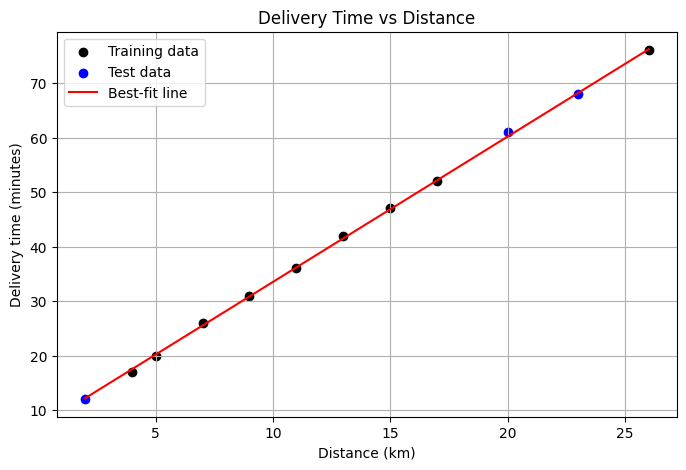

Predicted delivery time for 18 km: 54.8548 minutes


In [21]:
# TODO: Complete Task 7.
X = task7_df[["distance_km"]]
y = task7_df["delivery_time_minutes"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
print(f"Coefficient: {model.coef_[0]:.4f}")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

residuals = []
for i in range(len(y_test)):
    residuals.append(y_test.values[i] - y_pred[i])

residual_table = pd.DataFrame({
    "distance_km": X_test["distance_km"].values,
    "actual_time": y_test.values,
    "predicted_time": y_pred,
    "residual": residuals
})
display(residual_table)

line_predictions = model.predict(X)

plt.figure(figsize=(8, 5))
plt.scatter(X_train["distance_km"], y_train, color="black", label="Training data")
plt.scatter(X_test["distance_km"], y_test, color="blue", label="Test data")
plt.plot(X["distance_km"], line_predictions, color="red", label="Best-fit line")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery time (minutes)")
plt.title("Delivery Time vs Distance")
plt.legend()
plt.grid(True)
plt.show()

new_distance = pd.DataFrame({"distance_km": [18]})
new_prediction = model.predict(new_distance)
print(f"Predicted delivery time for 18 km: {new_prediction[0]:.4f} minutes")


### Interpretation Questions

1. What does `coef_[0]` mean?
2. Why are test metrics more meaningful than training metrics?
3. What does a positive residual mean when residual = actual − predicted?
4. Does `LinearRegression` expose a learning rate?

In [ ]:
# Write your answers as comments.
#  The slope.
#  They measure performance on data the model never saw, so they show how it generalises.
#  The model underpredicted, so the actual time was higher than the predicted time.
#  No, it solves for the parameters directly instead of using gradient descent.

# Task 8 — Multiple Linear Regression with `scikit-learn`

Predict employee performance using:

- Training hours
- Experience years
- Overtime hours

### Required

1. Train/test split.
2. Train Multiple Linear Regression.
3. Create a coefficient table.
4. Evaluate the model.
5. Predict a new employee.
6. Interpret all coefficients while holding other features constant.
7. Compare actual and predicted values.

In [22]:
task8_df = pd.DataFrame({
    "training_hours": [4, 8, 12, 5, 16, 20, 7, 14, 18, 10, 22, 25, 9, 13, 17, 21],
    "experience_years": [1, 2, 3, 1, 5, 6, 2, 4, 7, 3, 8, 9, 2, 5, 6, 8],
    "overtime_hours": [18, 15, 14, 20, 10, 8, 17, 12, 9, 15, 7, 6, 19, 11, 10, 7],
    "performance_score": [52, 58, 62, 50, 73, 81, 57, 69, 78, 64, 86, 91, 54, 71, 76, 87]
})

display(task8_df)

,training_hours,experience_years,overtime_hours,performance_score
0,4,1,18,52
1,8,2,15,58
2,12,3,14,62
3,5,1,20,50
4,16,5,10,73
5,20,6,8,81
6,7,2,17,57
7,14,4,12,69
8,18,7,9,78
9,10,3,15,64


In [23]:
# TODO: Complete Task 8.
feature_names = ["training_hours", "experience_years", "overtime_hours"]
X = task8_df[feature_names]
y = task8_df["performance_score"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)
print(f"Intercept: {model.intercept_:.4f}")

coefficient_rows = []
for i in range(len(feature_names)):
    coefficient_rows.append({
        "feature": feature_names[i],
        "coefficient": model.coef_[i]
    })

coefficient_table = pd.DataFrame(coefficient_rows)
display(coefficient_table)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

new_employee = pd.DataFrame({
    "training_hours": [15],
    "experience_years": [5],
    "overtime_hours": [12]
})
new_prediction = model.predict(new_employee)
print(f"Predicted performance score for the new employee: {new_prediction[0]:.4f}")

for i in range(len(feature_names)):
    print(f"{feature_names[i]}: each extra unit changes the predicted score by {model.coef_[i]:.4f}, holding the other features constant.")

residuals = []
for i in range(len(y_test)):
    residuals.append(y_test.values[i] - y_pred[i])

comparison_table = pd.DataFrame({
    "actual_score": y_test.values,
    "predicted_score": y_pred,
    "residual": residuals
})
display(comparison_table)


Training rows: 12
Test rows: 4
Intercept: 66.7882


,feature,coefficient
0,training_hours,0.284304
1,experience_years,2.517077
2,overtime_hours,-1.032869


MAE: 0.7086
MSE: 0.8466
RMSE: 0.9201
R2: 0.9942
Predicted performance score for the new employee: 71.2437
training_hours: each extra unit changes the predicted score by 0.2843, holding the other features constant.
experience_years: each extra unit changes the predicted score by 2.5171, holding the other features constant.
overtime_hours: each extra unit changes the predicted score by -1.0329, holding the other features constant.


,actual_score,predicted_score,residual
0,52,51.850825,0.149175
1,58,58.603724,-0.603724
2,81,79.313762,1.686238
3,76,76.395112,-0.395112


### Interpretation Questions

1. Which coefficient is positive and which is negative?
2. What does the overtime coefficient mean?
3. Why must coefficient interpretation include “holding other variables constant”?
4. Can we rank importance using raw coefficient size alone?

In [28]:
# Write your answers as comments.
# Training hours (0.28) and experience years (2.52) are positive, overtime hours (-1.03) is negative.
# Each extra overtime hour lowers the predicted score by about 1.03, holding the other features constant.
# Because the features are correlated, so without it one feature would get credit for the others' effect.
# No, the units differ, so a bigger coefficient does not mean a more important feature.

# Task 9 — Debugging Regression Training

For each case below, explain the most likely problem and the correct action.

### Case A
The cost starts at 500 and becomes:

`500, 900, 1800, 4200, 10000`

### Case B
The cost becomes:

`500, 499.8, 499.6, 499.4, 499.2`

after many iterations.

### Case C
Training R² is high, but test R² is much lower.

### Case D
All predictions are systematically lower than actual values.

### Case E
The slope is positive, but a student claims this proves that \(X\) causes \(Y\).

In [29]:
# Write your diagnosis and recommendation for each case.

# Case A: The learning rate is too large, so the cost diverges. Lower it, for example from 0.1 to 0.01.

# Case B: The learning rate is too small, so the cost barely moves. Raise it or run more iterations.

# Case C: The model overfits the training data. Use fewer features or more data.

# Case D: The intercept is too low, so the model underfits. Train longer or check for a missing feature.

# Case E: A positive slope only shows association, not causation. Another variable could explain the link.

# Final Challenge — Complete Regression Workflow

Choose either Simple or Multiple Linear Regression.

Your analysis must include:

1. Problem definition
2. Feature(s) and target
3. Visualization
4. Train/test split
5. Model training
6. Intercept and coefficient interpretation
7. Predictions
8. MAE, MSE, RMSE, and R²
9. Residual table
10. Best-fit line if applicable
11. Three insights
12. Two limitations
13. Final conclusion

Problem: predict an employee performance score from training hours, experience years and overtime hours.
Model: Multiple Linear Regression.
Features: ['training_hours', 'experience_years', 'overtime_hours']
Target: performance_score


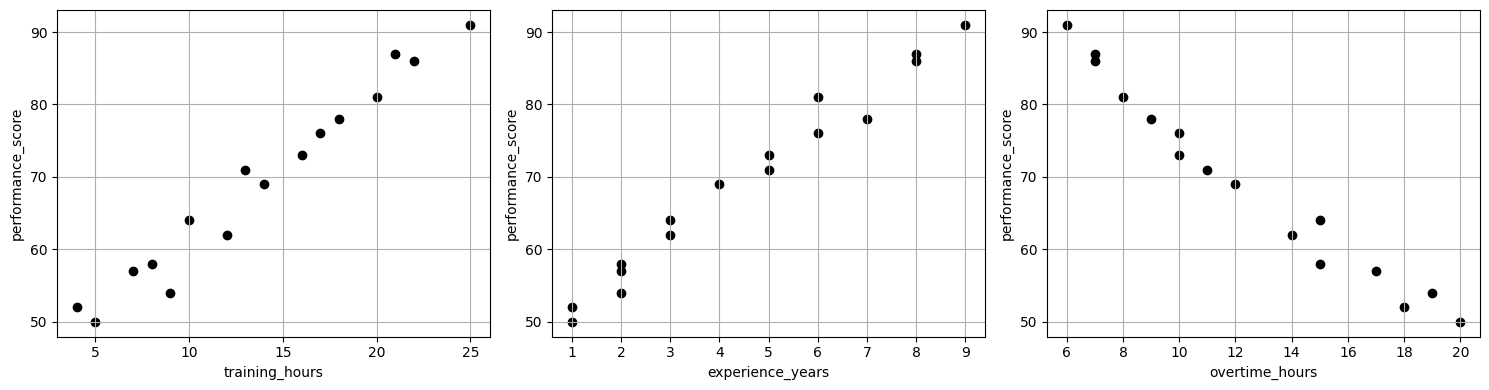

Training rows: 12
Test rows: 4
Intercept: 66.7882
training_hours: 0.2843 points per unit, holding the other features constant.
experience_years: 2.5171 points per unit, holding the other features constant.
overtime_hours: -1.0329 points per unit, holding the other features constant.
MAE: 0.7086
MSE: 0.8466
RMSE: 0.9201
R2: 0.9942


,training_hours,experience_years,overtime_hours,actual_score,predicted_score,residual
0,4,1,18,52,51.850825,0.149175
1,8,2,15,58,58.603724,-0.603724
2,20,6,8,81,79.313762,1.686238
3,17,6,10,76,76.395112,-0.395112


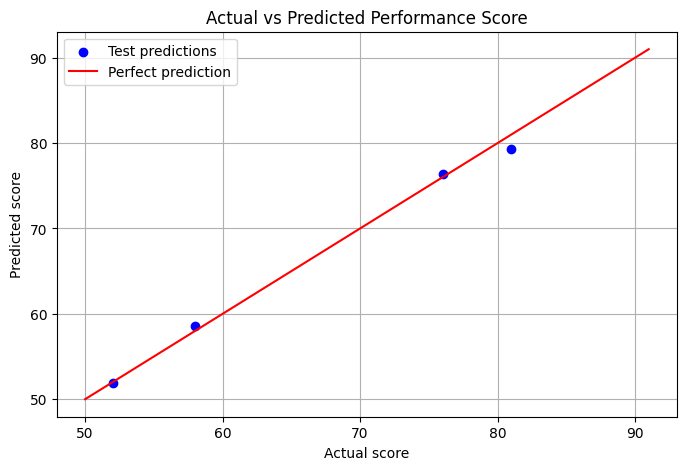

Insight 1: experience years has the strongest effect per unit, adding about 2.52 points per year.
Insight 2: overtime hours is the only negative feature, so more overtime is linked to lower scores.
Insight 3: the test R2 is very high, so the three features explain almost all of the variation in the score.
Limitation 1: the dataset has only 16 rows, so the metrics depend heavily on which rows land in the test set.
Limitation 2: the coefficients show association only and do not prove that overtime causes lower performance.
Conclusion: the model predicts performance accurately on unseen data, with experience and training raising the predicted score and overtime lowering it.


In [30]:
# Complete your final challenge here.
print("Problem: predict an employee performance score from training hours, experience years and overtime hours.")
print("Model: Multiple Linear Regression.")

feature_names = ["training_hours", "experience_years", "overtime_hours"]
target_name = "performance_score"
print("Features:", feature_names)
print("Target:", target_name)

plt.figure(figsize=(15, 4))
for i in range(len(feature_names)):
    plt.subplot(1, 3, i + 1)
    plt.scatter(task8_df[feature_names[i]], task8_df[target_name], color="black")
    plt.xlabel(feature_names[i])
    plt.ylabel(target_name)
    plt.grid(True)
plt.tight_layout()
plt.show()

X = task8_df[feature_names]
y = task8_df[target_name]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Intercept: {model.intercept_:.4f}")
for i in range(len(feature_names)):
    print(f"{feature_names[i]}: {model.coef_[i]:.4f} points per unit, holding the other features constant.")

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

residuals = []
for i in range(len(y_test)):
    residuals.append(y_test.values[i] - y_pred[i])

residual_table = pd.DataFrame({
    "training_hours": X_test["training_hours"].values,
    "experience_years": X_test["experience_years"].values,
    "overtime_hours": X_test["overtime_hours"].values,
    "actual_score": y_test.values,
    "predicted_score": y_pred,
    "residual": residuals
})
display(residual_table)

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color="blue", label="Test predictions")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", label="Perfect prediction")
plt.xlabel("Actual score")
plt.ylabel("Predicted score")
plt.title("Actual vs Predicted Performance Score")
plt.legend()
plt.grid(True)
plt.show()

print("Insight 1: experience years has the strongest effect per unit, adding about 2.52 points per year.")
print("Insight 2: overtime hours is the only negative feature, so more overtime is linked to lower scores.")
print("Insight 3: the test R2 is very high, so the three features explain almost all of the variation in the score.")

print("Limitation 1: the dataset has only 16 rows, so the metrics depend heavily on which rows land in the test set.")
print("Limitation 2: the coefficients show association only and do not prove that overtime causes lower performance.")

print("Conclusion: the model predicts performance accurately on unseen data, with experience and training raising the predicted score and overtime lowering it.")
